## Decode self-prediciton

Self predict the 3D calibration set.  For an isolated bead we should get linear z positions as a function of image, since the images represent a stack (not a series)

In [51]:
import sys

import decode
import decode.utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import os
from wip_util import zero_pad_index
from skimage.io import imread

print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

# set device and num threads
device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 3  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

frame_path = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\1a - Astigmatic_Widefield_scaffold_Z-Stack_RAW_TIFF_IMAGE.tif'
out_path = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\selfprediction2'
model_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-27-2class-c\decode_model_0.pt'
param_path = r'D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-27-2class-c\params.yaml'

#frame_path = r'/home/bnorthan/janelia_slm/data/calibrations/Janelia PALM RUN2/1a - Astigmatic_Widefield_scaffold_Z-Stack_RAW_TIFF_IMAGE.tif'
#out_path = r'/home/bnorthan/janelia_slm/data/calibrations/Janelia PALM RUN2/selfprediction'
#model_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-2class-c/decode_model_0.pt'
#param_path = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/models/2025-06-27-2class-c/params.yaml'

fig_path = os.path.join(out_path, 'figures')

if not os.path.exists(out_path):
    os.makedirs(out_path)

if not os.path.exists(fig_path):
    os.makedirs(fig_path)


DECODE version: v0.10.2-19-g5dc78eb-dirty


## Load parameters and model

In [52]:
param = decode.utils.param_io.load_params(param_path)
model = decode.neuralfitter.models.SigmaMUNet.parse(param)
model = decode.utils.model_io.LoadSaveModel(model,
                                            input_file=model_path,
                                            output_file=None).load_init(device=device)
camera = decode.simulation.camera.Photon2Camera.parse(param)
camera.device = 'cpu'

Model instantiated.
Model SHA-1 hash: 729020a4849b604e0fb98e4828fa986b4d318f27
Loaded pretrained model: D:\Janelia_slm_data\models\Janelia PALM RUN2\2025-06-27-2class-c\decode_model_0.pt


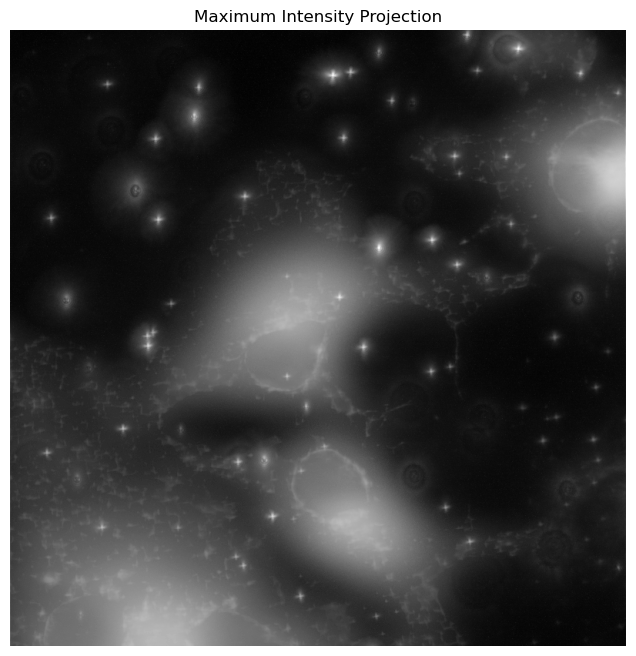

In [53]:
frames = imread(frame_path)
# Compute maximum intensity projection (MIP)
max_projection = np.log1p(np.max(frames, axis=0))  # Collapse along depth
# Display the MIP using matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(max_projection, cmap='gray')
plt.axis("off")
plt.title("Maximum Intensity Projection")
plt.show()


## Setup frames preprocessing

In [54]:
frames_ = torch.tensor(frames[:10].astype('float32'), dtype=torch.float32, device=device)

# setup frame processing as by the parameter with which the model was trained
frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.utils.processing.wrap_callable(camera.backward),
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    #decode.neuralfitter.frame_processing.Mirror2D(dims=-1),  # WARNING: You might need to comment this line out. see above
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param)
])

# determine extent of frame and its dimension after frame_processing
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames_.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))


# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
post_proc = decode.neuralfitter.utils.processing.TransformSequence([

    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),

    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),

    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)


])

infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                  frame_proc=frame_proc, post_proc=post_proc,
                                  device=device, num_workers=worker)

infer.batch_size = 1 

In [55]:
frames = torch.tensor(frames.astype('float32'), dtype=torch.float32, device=device) 
print(f"Frames shape: {frames.shape}")
emitters = infer.forward(frames)

print(emitters)
    

Frames shape: torch.Size([601, 800, 800])


100%|██████████| 601/601 [01:37<00:00,  6.17it/s]


EmitterSet
::num emitters: 2147787
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [-5.0909954e-01 -6.9191885e-01 -1.3138126e+03] - [ 799.5572  799.4738 1306.3341]


In [56]:
sigma_x_high_threshold = 20
sigma_y_high_threshold = 20
sigma_z_high_threshold = 50
prob_threshold = 0.98

print(emitters)

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    ]

print(emitters_filtered)

EmitterSet
::num emitters: 2147787
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [-5.0909954e-01 -6.9191885e-01 -1.3138126e+03] - [ 799.5572  799.4738 1306.3341]
EmitterSet
::num emitters: 17999
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 1.1580237e-01 -5.2924204e-01 -1.2977173e+03] - [ 795.4392  796.1117 1299.5315]


In [57]:
import napari
viewer = napari.Viewer()
viewer.add_image(frames.cpu().numpy(), name='Frames', colormap='gray')

<Image layer 'Frames' at 0x16d49be0130>

In [58]:
from wip_util import get_np_points
points = get_np_points(emitters_filtered, 0, 600, True)
print(points.shape)
#points = points[points[:,0] == points[0,0]]
print(points.shape)
points_ = points[:, 0:3]
viewer.add_points(points_, name='Emitters', size=5, face_color='blue')

(17990, 4)
(17990, 4)


<Points layer 'Emitters' at 0x17053472be0>

In [59]:
viewer2 = napari.Viewer()
frames_cropped = frames[:, 110:170, 160:220]
viewer2.add_image(frames_cropped.cpu().numpy(), name='Frames')

<Image layer 'Frames' at 0x170576ed820>

In [60]:
bead = emitters_filtered[
    (emitters_filtered.xyz_px[:, 1]>= 160) & (emitters_filtered.xyz_px[:, 1] <= 220) &
    (emitters_filtered.xyz_px[:, 0]>= 110) & (emitters_filtered.xyz_px[:, 0] <= 170) 
    #(emitters_filtered.frame_ix==29)
]

print(bead.xyz_px[0])


bead_points = get_np_points(bead, 0, 600, True)
print(bead_points[0])

bead_points_ = bead_points[:, 0:3]
bead_points_[:, 1] -= 110  # Adjust x-coordinates to match cropped image
bead_points_[:, 2] -= 160  # Adjust y-coordinates to match cropped image
print(bead_points_[0])
viewer2.add_points(bead_points_, name='Bead Emitters', size=2, face_color='red')

print(bead_points)


tensor([ 140.9763,  188.9914, 1269.8022])
[ 101.          140.97627258  188.99137878 1269.80224609]
[101.          30.97627258  28.99137878]
[[ 101.           30.97627258   28.99137878 1269.80224609]
 [ 102.           30.98529053   29.05128479 1270.21569824]
 [ 103.           30.99208069   29.06793213 1271.50256348]
 ...
 [ 584.           31.39787292   29.07202148 -859.95843506]
 [ 585.           31.31729126   29.1933136  -854.28088379]
 [ 586.           31.45759583   29.40849304 -941.14978027]]


In [61]:
def get_roi(emitters, xc, yc, window_size):
    """
    Extracts a region of interest (ROI) from emitters based on a specified center and window size.
    
    Parameters:
    - emitters: Emitter data containing coordinates and other properties.
    - xc: x-coordinate of the center.
    - yc: y-coordinate of the center.
    - window_size: Size of the window to extract around the center.
    
    Returns:
    - roi: Emitter points within the specified window around the center.
    """
    roi = emitters[(
        (emitters.xyz_px[:, 1] >= xc-window_size) & (emitters.xyz_px[:, 1] < xc + window_size) &
        (emitters.xyz_px[:, 0] >= yc-window_size) & (emitters.xyz_px[:, 0] < yc + window_size)
    )]
    
    return roi

def get_bead_points(emitters, xc, yc, window_size, nframes):
    """
    Extracts bead points from emitters based on a specified center and window size.
    
    Parameters:
    - emitters: Emitter data containing coordinates and other properties.
    - xc: x-coordinate of the center.
    - yc: y-coordinate of the center.
    - window_size: Size of the window to extract around the center.
    
    Returns:
    - bead_points: Points within the specified window around the center.
    """
    emitter = emitters[(
        (emitters.xyz_px[:, 1] >= xc-window_size) & (emitters.xyz_px[:, 1] < xc + window_size) &
        (emitters.xyz_px[:, 0] >= yc-window_size) & (emitters.xyz_px[:, 0] < yc + window_size)
    )]

    bead_points = get_np_points(emitter, 0, nframes, True)

    bead_points_ = bead_points[:, 0:3]
    bead_points_[:, 2] -= xc-window_size  # Adjust x-coordinates to match cropped
    bead_points_[:, 1] -= yc-window_size  # Adjust y-coordinates to match cropped image

    return bead_points, bead_points_


In [63]:
from wip_util import smap_csv_to_emitters
smap_input_file = r'D:\Janelia_slm_data\calibrations\Janelia PALM RUN2\selfprediction\SMAP_full.csv'
#smap_input_file = r'/home/bnorthan/janelia_slm/data/calibrations/Janelia PALM RUN2/selfprediction/SMAP_full.csv'
smap_emitters = smap_csv_to_emitters(smap_input_file, 100, True)
print(smap_emitters)
smap_points = get_np_points(smap_emitters, 0, 400)
viewer.add_points(smap_points, name = 'smap points', face_color='cyan', size=2)

EmitterSet
::num emitters: 247018
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 3.258679e+00  1.594135e+00 -1.970000e+03] - [ 806.1168  810.6002 2000.    ]


<Points layer 'smap points' at 0x16fe21ecbe0>

In [64]:
sigma_x_high_threshold, sigma_y_high_threshold, sigma_z_high_threshold = 7, 7, 25

In [65]:
print(smap_emitters)

smap_emitters_filtered = smap_emitters[
    (smap_emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (smap_emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (smap_emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (smap_emitters.prob >= prob_threshold)
    ]

print(smap_emitters_filtered)

EmitterSet
::num emitters: 247018
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [ 3.258679e+00  1.594135e+00 -1.970000e+03] - [ 806.1168  810.6002 2000.    ]
EmitterSet
::num emitters: 22189
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [    5.578719    42.19191  -1970.      ] - [ 797.7321  797.4099 1995.352 ]


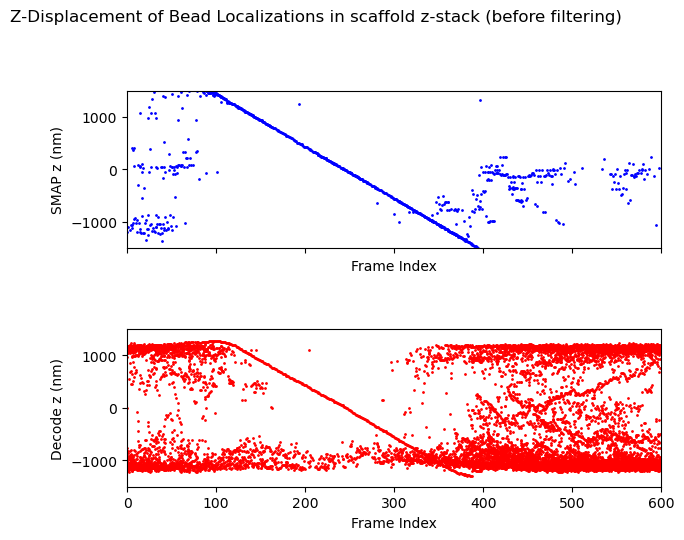

In [66]:
smap_points, smap_points_ = get_bead_points(smap_emitters, 190, 140, 30, 600)
bead_points, bead_points_ = get_bead_points(emitters, 190, 140, 30, 600)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(smap_points[:, 0], smap_points[:, 3], s=1, color='blue')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('SMAP z (nm)')
ax1.set_xlim(0, 600)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points[:, 0], bead_points[:, 3], s=1, color='red')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Decode z (nm)')
ax2.set_xlim(0, 600)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-Displacement of Bead Localizations in scaffold z-stack (before filtering)')

fig.savefig(os.path.join(fig_path, 'bead_z_displacement_before_filtering.png'), dpi=300)

plt.tight_layout()
plt.show()



Text(0.5, 0.98, 'Total Sigma of Bead Localizations in scaffold z-stack (before filtering)')

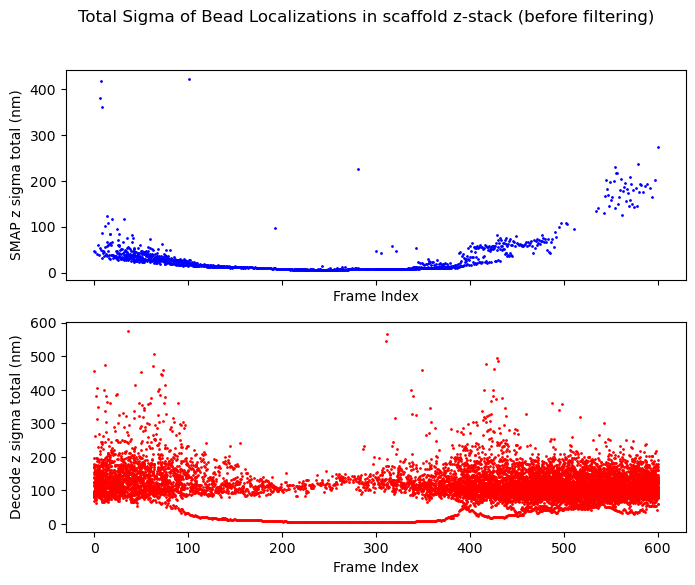

In [72]:
emitters_roi = get_roi(emitters, 190, 140, 30)
smap_emitters_roi = get_roi(smap_emitters, 190, 140, 30)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.scatter(smap_emitters_roi.frame_ix, smap_emitters_roi.xyz_sig_tot_nm, s=1, color='blue')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('SMAP z sigma total (nm)')

ax2.scatter(emitters_roi.frame_ix, emitters_roi.xyz_sig_tot_nm, s=1, color='red')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Decode z sigma total (nm)')

fig.suptitle('Total Sigma of Bead Localizations in scaffold z-stack (before filtering)')

EmitterSet
::num emitters: 2147787
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [-5.0909954e-01 -6.9191885e-01 -1.3138126e+03] - [ 799.5572  799.4738 1306.3341]
EmitterSet
::num emitters: 9044
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 0 - 600
::spanned volume: [    3.0958657    32.07804   -1297.7173   ] - [ 761.0462   789.98914 1290.3328 ]


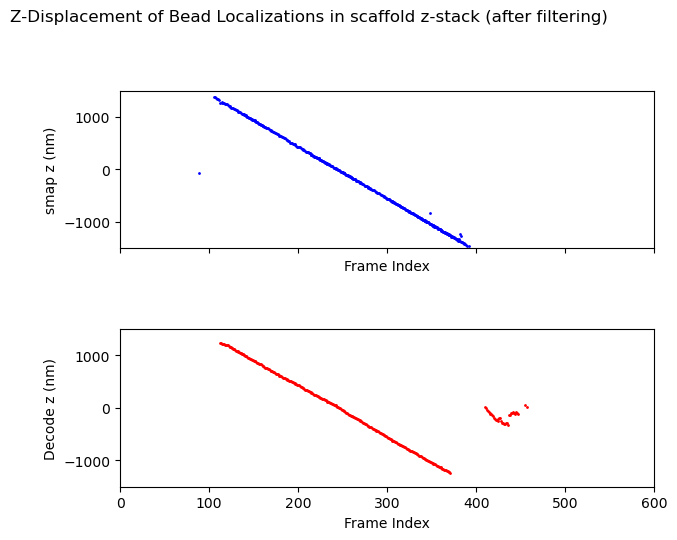

In [81]:
sigma_x_high_threshold = 10
sigma_y_high_threshold = 10
sigma_z_high_threshold = 30
prob_threshold = 0.98

print(emitters)

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    ]

print(emitters_filtered)

smap_points, smap_points_ = get_bead_points(smap_emitters_filtered, 190, 140, 30, 600)
bead_points, bead_points_ = get_bead_points(emitters_filtered, 190, 140, 30, 600)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(smap_points[:, 0], smap_points[:, 3], s=1, color='blue')
ax1.set_ylabel('smap z (nm)')
ax1.set_xlabel('Frame Index')
ax1.set_xlim(0, 600)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points[:, 0], bead_points[:, 3], s=1, color='red')
ax2.set_ylabel('Decode z (nm)')
ax2.set_xlabel('Frame Index')
ax2.set_xlim(0, 600)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-Displacement of Bead Localizations in scaffold z-stack (after filtering)')

fig.savefig(os.path.join(fig_path, 'bead_z_displacement_after_filtering.png'), dpi=300)

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'Total Sigma of Bead Localizations in scaffold z-stack (after filtering)')

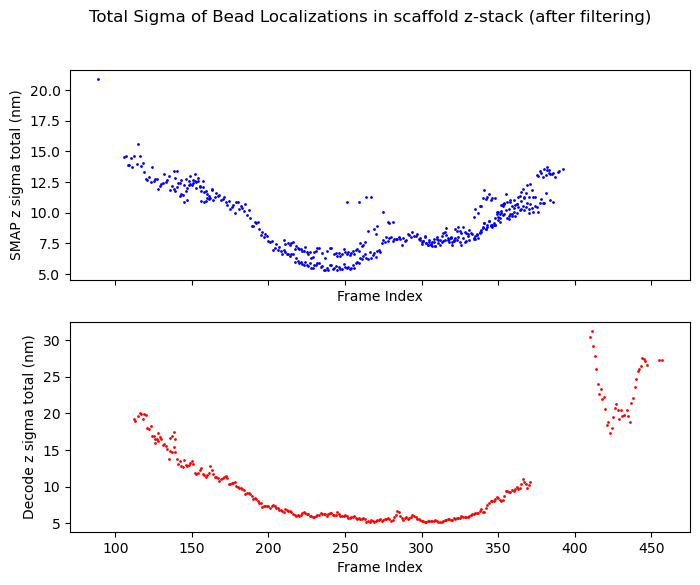

In [80]:
emitters_roi = get_roi(emitters_filtered, 190, 140, 30)
smap_emitters_roi = get_roi(smap_emitters_filtered, 190, 140, 30)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.scatter(smap_emitters_roi.frame_ix, smap_emitters_roi.xyz_sig_tot_nm, s=1, color='blue')
ax1.set_xlabel('Frame Index')
ax1.set_ylabel('SMAP z sigma total (nm)')

ax2.scatter(emitters_roi.frame_ix, emitters_roi.xyz_sig_tot_nm, s=1, color='red')
#ax2.scatter(emitters_roi.frame_ix, emitters_roi.xyz_nm[:,2], s=1, color='red')
ax2.set_xlabel('Frame Index')
ax2.set_ylabel('Decode z sigma total (nm)')

fig.suptitle('Total Sigma of Bead Localizations in scaffold z-stack (after filtering)')

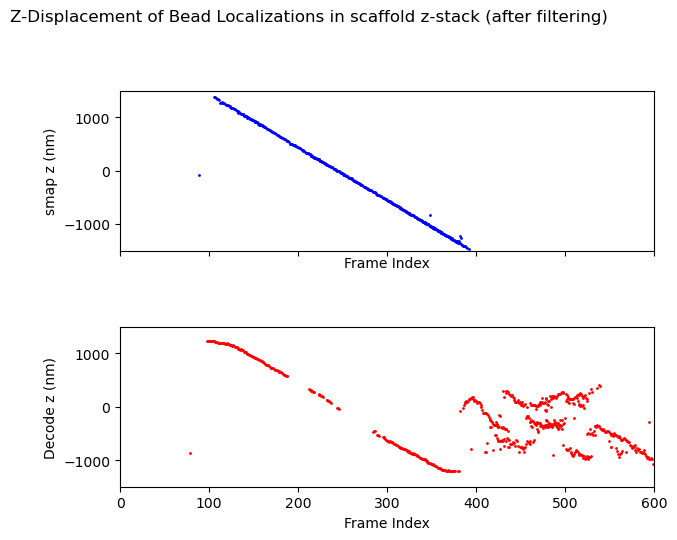

In [19]:
smap_points, smap_points_ = get_bead_points(smap_emitters_filtered, 190, 140, 30, 600)
bead_points, bead_points_ = get_bead_points(emitters_filtered, 190, 140, 30, 600)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

# Top plot: smap_points
ax1.scatter(smap_points[:, 0], smap_points[:, 3], s=1, color='blue')
ax1.set_ylabel('smap z (nm)')
ax1.set_xlabel('Frame Index')
ax1.set_xlim(0, 600)
ax1.set_ylim(-1500, 1500)

# Bottom plot: bead_points
ax2.scatter(bead_points[:, 0], bead_points[:, 3], s=1, color='red')
ax2.set_ylabel('Decode z (nm)')
ax2.set_xlabel('Frame Index')
ax2.set_xlim(0, 600)
ax2.set_ylim(-1500, 1500)

fig.suptitle('Z-Displacement of Bead Localizations in scaffold z-stack (after filtering)')

fig.savefig(os.path.join(fig_path, 'bead_z_displacement_after_filtering.png'), dpi=300)

plt.tight_layout()
plt.show()

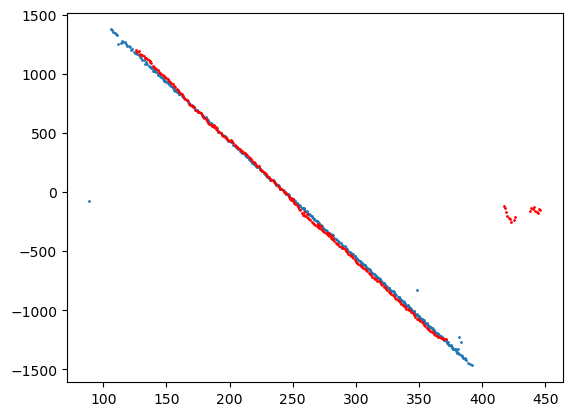

In [73]:
plt.scatter(smap_points[:, 0], smap_points[:, 3], s=1)
plt.scatter(bead_points[:, 0], bead_points[:, 3], s=1, c='red')

In [22]:
smap_emitters.xyz_sig_nm[:, 0].mean(), smap_emitters.xyz_sig_nm[:, 1].mean(), smap_emitters.xyz_sig_nm[:, 2].mean()

(tensor(28.4169, dtype=torch.float64),
 tensor(28.4169, dtype=torch.float64),
 tensor(77.5954, dtype=torch.float64))

In [43]:
points[:,0].max(), points[:,1].max(), points[:,2].max(), points[:,3].max()

(399.0, 35.30611801147461, 33.67400360107422, 800.5736083984375)

In [44]:
points_ = points_[:, [0, 2, 1]]  # Reorder to (x, z, y) for napari
points_ 

array([[  1.        ,  24.86883163,  23.416605  ],
       [  3.        ,  22.96732521,  27.42010307],
       [  7.        ,  23.09608269,  27.47601891],
       ...,
       [398.        ,  29.8085537 ,  27.4239769 ],
       [399.        ,  26.2452755 ,  22.59160995],
       [399.        ,  29.73130798,  27.38652992]])